# 🏠 MietCheck · 🔍 QUA³CK-Phase 2: Understanding the Data

**Modul:** Data Analytics & Big Data (IU, 4. Semester) · **Projekt:** MietCheck – „Zahle ich zu viel Miete?"

> Teil 2 von 6 der QUA³CK-Notebook-Serie. Reihenfolge:
> **Q**ualitätsprüfung → **U**nderstanding → **A**lgorithmenauswahl →
> Modellentwicklung → **C**ross-Validation → **K**nowledge.

**Ziel:** die Daten wirklich *verstehen* – Verteilungen, regionale Unterschiede und Zusammenhänge. Das ist laut QUA³CK die zentrale Phase (45–80 % der ML-Arbeit).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import config as C
sns.set_theme(style='whitegrid', palette='rocket')
print('Setup ok ·', ROOT.name)

Setup ok · MietCheck


In [2]:
df = pd.read_parquet(C.CLEAN_PARQUET)
df['eur_sqm'] = df[C.TARGET]/df['livingSpace']
print(f'{len(df):,} Wohnungen · {df.shape[1]} Merkmale')
df[C.NUMERIC_FEATURES+[C.TARGET]].describe().round(1)

202,908 Wohnungen · 16 Merkmale


,livingSpace,noRooms,yearConstructed,baseRent
count,202908.0,202908.0,202908.0,202908.0
mean,73.3,2.6,1970.9,648.9
std,30.2,0.9,35.6,480.6
min,15.0,1.0,1900.0,100.0
25%,54.9,2.0,1954.0,336.6
50%,67.2,3.0,1974.0,490.0
75%,86.0,3.0,1997.0,800.0
max,300.0,8.0,2022.0,6000.0


## 1. Verteilung der Zielgröße
Die Kaltmiete ist rechtsschief – logarithmiert wird sie ~normal.

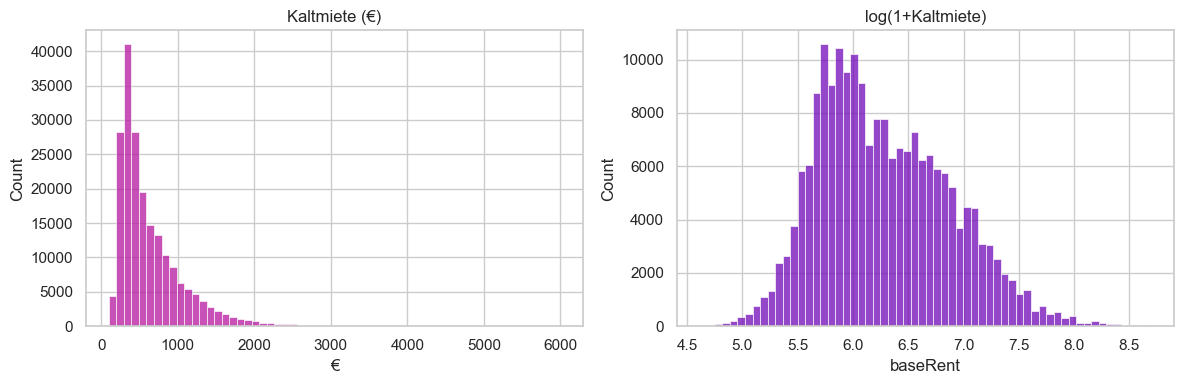

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df[C.TARGET], bins=60, ax=ax[0], color='#b5179e')
ax[0].set(title='Kaltmiete (€)', xlabel='€')
sns.histplot(np.log1p(df[C.TARGET]), bins=60, ax=ax[1], color='#7209b7')
ax[1].set(title='log(1+Kaltmiete)'); plt.tight_layout(); plt.show()

## 2. Regionale Unterschiede (der USP-Kern)
Miete pro m² variiert massiv nach Bundesland.

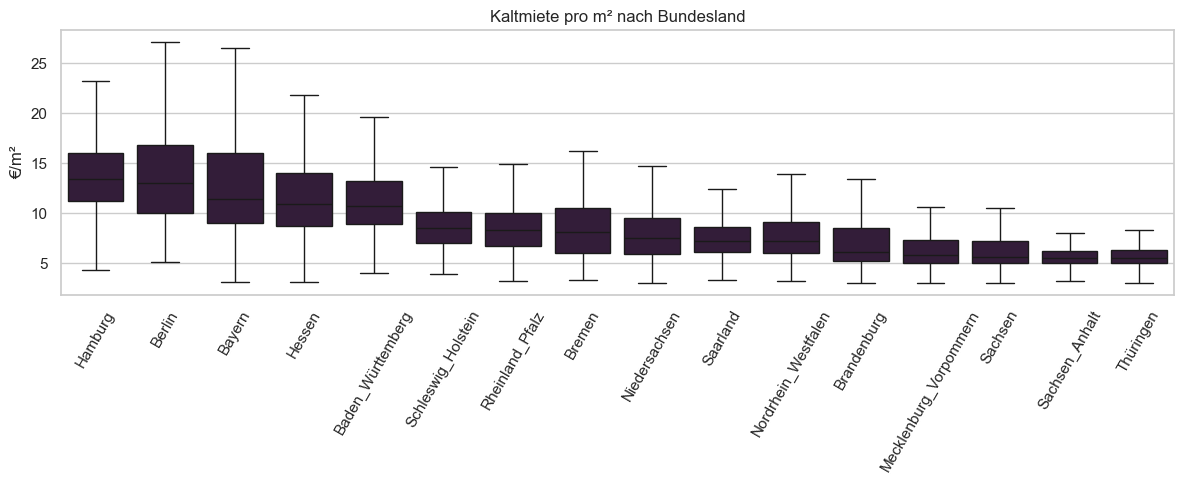

In [4]:
order = df.groupby('regio1')['eur_sqm'].median().sort_values(ascending=False).index
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='regio1', y='eur_sqm', order=order, showfliers=False)
plt.xticks(rotation=60); plt.ylabel('€/m²'); plt.xlabel('')
plt.title('Kaltmiete pro m² nach Bundesland'); plt.tight_layout(); plt.show()

## 3. Zusammenhänge (Korrelation)

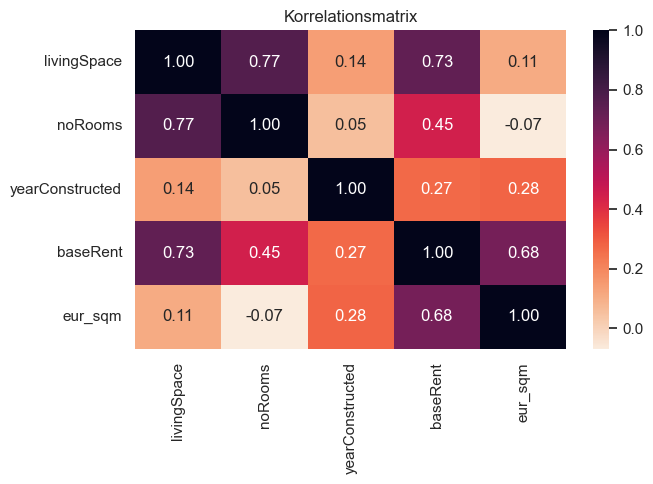

Wohnfläche korreliert am stärksten mit der Miete.


In [5]:
num = df[C.NUMERIC_FEATURES+[C.TARGET,'eur_sqm']]
plt.figure(figsize=(7,5)); sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='rocket_r')
plt.title('Korrelationsmatrix'); plt.tight_layout(); plt.show()
print('Wohnfläche korreliert am stärksten mit der Miete.')

## 4. Fläche vs. Miete

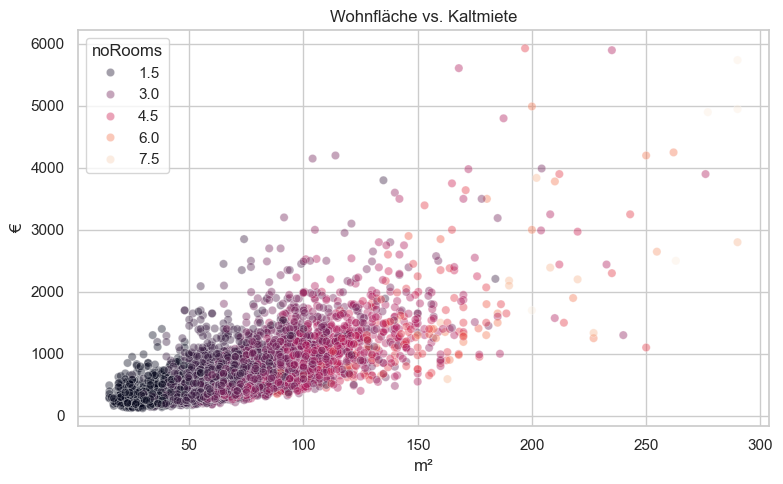

In [6]:
s = df.sample(6000, random_state=1)
plt.figure(figsize=(8,5))
sns.scatterplot(data=s, x='livingSpace', y=C.TARGET, hue='noRooms', alpha=0.4, palette='rocket')
plt.title('Wohnfläche vs. Kaltmiete'); plt.xlabel('m²'); plt.ylabel('€'); plt.tight_layout(); plt.show()

## 5. Kategoriale Merkmale

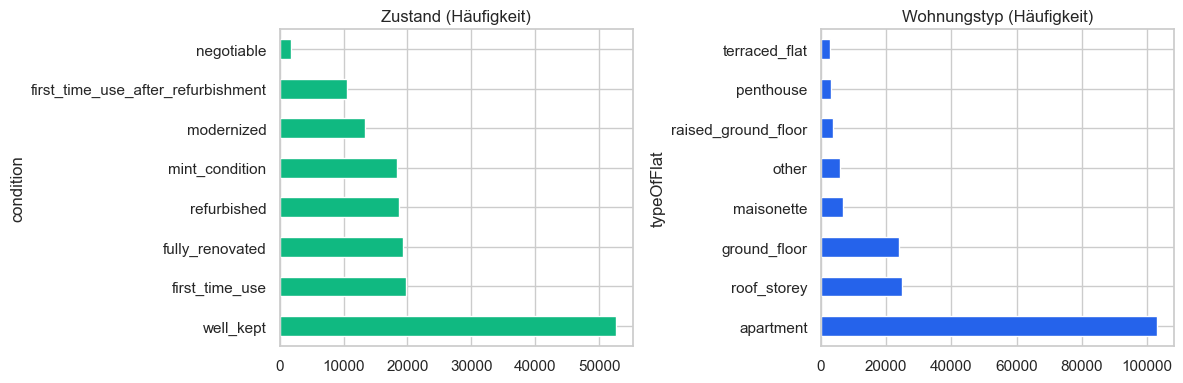

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
df['condition'].value_counts().head(8).plot.barh(ax=ax[0], color='#10b981')
ax[0].set(title='Zustand (Häufigkeit)')
df['typeOfFlat'].value_counts().head(8).plot.barh(ax=ax[1], color='#2563eb')
ax[1].set(title='Wohnungstyp (Häufigkeit)'); plt.tight_layout(); plt.show()

## ✅ Fazit Phase U
- Zielgröße rechtsschief; **Wohnfläche** ist stärkster numerischer Treiber.
- **Region** (Bundesland/Stadt) erklärt große Preisunterschiede → wichtig fürs Modell.
- Kategoriale Merkmale (Zustand, Typ) sind ungleich verteilt → beim Encoding beachten.

➡️ Weiter mit **03 · Algorithmenauswahl**.